# Pandas Hands-on Lab: From Tables to Real Analysis

## Student Practice Notebook

**Name:** K.Satya Ganesh  
**Register Number:** AP24110010736  
**Date:** 14-08-2026  

## Learning Objectives

After completing this lab, you will be able to:

- Load and inspect a real dataset with pandas
- Select, filter, and sort rows and columns
- Create new columns from existing ones
- Explore categorical data with `value_counts()`
- Clean data: handle duplicates, missing values, wrong dtypes, and column names
- Summarize data with `groupby()`
- Combine two related tables with `merge()`
- Visualize a DataFrame with matplotlib
- Save your results back to a file

### How to use this notebook
This continues directly from last week's NumPy lab — pandas is built on top of NumPy arrays, so everything you already know about arrays applies here, just organized into labeled rows and columns (a **DataFrame**).

- **Demonstration** cells: run and read.
- **Practice** cells: write your own code.
- **Predict-then-run**: write your prediction before running.
- **Reflection**: short written answers in your own words.


## Part 1: Loading and Inspecting Data

We'll use the classic **tips** dataset — real restaurant bill data. Each row is one bill.

### Demonstration


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', 10)
pd.set_option('display.precision', 3)

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
tips = pd.read_csv(url)
tips.head(200)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
195,7.56,1.44,Male,No,Thur,Lunch,2
196,10.34,2.00,Male,Yes,Thur,Lunch,2
197,43.11,5.00,Female,Yes,Thur,Lunch,4
198,13.00,2.00,Female,Yes,Thur,Lunch,2


**Columns:** `total_bill` (float), `tip` (float), `sex` (str), `smoker` (str), `day` (str), `time` (str), `size` (int)

A pandas **DataFrame** is a 2D table, similar to a NumPy 2D array, but with labeled columns and an index for each row.


In [6]:
print("Shape:", tips.shape)
print("\nInfo:")
tips.info()


Shape: (244, 7)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


### Student Practice

1. Print `tips.describe()` to see summary statistics.
2. Print the column names using `tips.columns`.
3. Print just the last 5 rows using `tips.tail()`.


In [7]:
print(tips.describe())
print(tips.columns)
print(tips.tail())

       total_bill      tip     size
count     244.000  244.000  244.000
mean       19.786    2.998    2.570
std         8.902    1.384    0.951
min         3.070    1.000    1.000
25%        13.348    2.000    2.000
50%        17.795    2.900    2.000
75%        24.127    3.562    3.000
max        50.810   10.000    6.000
Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')
     total_bill   tip     sex smoker   day    time  size
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2


**Reflection:** `tips.shape` only tells us the number of rows and columns, such as `(244, 7)`. `tips.info()` gives much more detail: the index/range, column names, non-null counts, data types, number of entries, and memory usage. This makes `.info()` useful for understanding the structure and quality of a DataFrame.


tips.shape(NumPy-style) is only giving number of rows and columns like this (244,7) where as tips.info() is giving Range information , column names of dataFrame and count of Not-Null values of each column , datatype of easch column , how many columns are there belong to each column and also memory usage

## Part 2: Exploring Categorical Data with `value_counts()`

Before filtering or grouping, it helps to know what categories exist in a column and how common each is.

### Demonstration


In [8]:
tips['sex'].value_counts()


,count
sex,
Male,157
Female,87


### Student Practice

1. Use `value_counts()` on the `time` column. Which time period has more bills — Lunch or Dinner?
2. Use `value_counts()` on `smoker`. What percentage of customers were smokers? (Hint: `value_counts(normalize=True)` gives proportions instead of counts.)


In [9]:
# Write your answer here
print(tips['time'].value_counts(normalize=True))
print(tips['smoker'].value_counts(normalize=True))

time
Dinner    0.721
Lunch     0.279
Name: proportion, dtype: float64
smoker
No     0.619
Yes    0.381
Name: proportion, dtype: float64


In [ ]:
1.Ans)Dinner(176) has more bills
2.Ans)38.1 % customers are smokers

## Part 3: Selecting and Filtering

### Demonstration


In [11]:
# Select specific columns
tips[['total_bill','tip']].head()


,total_bill,tip
0,16.99,1.01
1,10.34,1.66
2,21.01,3.50
3,23.68,3.31
4,24.59,3.61


In [12]:
# Select rows by position
tips.iloc[0:5]


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [13]:
# Select rows by label/condition using .loc
tips.loc[tips['day']=='Sun' , ['total_bill','tip','size']].head()


,total_bill,tip,size
0,16.99,1.01,2
1,10.34,1.66,3
2,21.01,3.50,3
3,23.68,3.31,2
4,24.59,3.61,4


In [14]:
# Boolean filtering (same idea as NumPy boolean indexing!)
big_tables = tips[tips['size']>= 5]
big_tables.head()
big_table = tips[(tips['size']>=5) & (tips['time']=='Lunch')]
big_table.head()


,total_bill,tip,sex,smoker,day,time,size
125,29.80,4.2,Female,No,Thur,Lunch,6
141,34.30,6.7,Male,No,Thur,Lunch,6
142,41.19,5.0,Male,No,Thur,Lunch,5
143,27.05,5.0,Female,No,Thur,Lunch,6


**Note the parallel to NumPy:** `tips[tips['size'] >= 5]` uses a boolean condition to filter rows — exactly like `marks[marks > 60]` did with NumPy arrays in last week's lab. The DataFrame version just keeps the whole row instead of a single value.


### Student Practice — predict then check

Before running: **My prediction:** This should be a small subset of the 244 rows because a row must satisfy both conditions at the same time: the customer must be a smoker and the visit must be during Lunch.


In [ ]:
# Run your filter here and check your prediction
example_table = tips[(tips['smoker']=='Yes')&(tips['time']=='Lunch')]
print(len(example_table))

23


## Part 4: Sorting

### Demonstration


In [15]:
tips_sorted = tips.sort_values(['tip','total_bill'] , ascending = [True , False])
tips_sorted

,total_bill,tip,sex,smoker,day,time,size
236,12.60,1.00,Male,Yes,Sat,Dinner,2
111,7.25,1.00,Female,No,Sat,Dinner,1
92,5.75,1.00,Female,Yes,Fri,Dinner,2
67,3.07,1.00,Female,Yes,Sat,Dinner,1
0,16.99,1.01,Female,No,Sun,Dinner,2
...,...,...,...,...,...,...,...
141,34.30,6.70,Male,No,Thur,Lunch,6
59,48.27,6.73,Male,No,Sat,Dinner,4
23,39.42,7.58,Male,No,Sat,Dinner,4
212,48.33,9.00,Male,No,Sat,Dinner,4


### Student Practice

Sort `tips` by `tip` in descending order and display the top 5 highest tips. Which day(s) do they mostly occur on?

**Answer:** The top 5 highest tips occur mostly on **Saturday**, with some occurring on **Sunday**.


In [16]:
# Sort by tip in descending order and display the top 5
sort_by_tip = tips.sort_values('tip', ascending=False)
top_5_tips = sort_by_tip.head(5)
print(top_5_tips)
print("Day counts among the top 5:")
print(top_5_tips['day'].value_counts())


     total_bill    tip   sex smoker   day    time  size
170       50.81  10.00  Male    Yes   Sat  Dinner     3
212       48.33   9.00  Male     No   Sat  Dinner     4
23        39.42   7.58  Male     No   Sat  Dinner     4
59        48.27   6.73  Male     No   Sat  Dinner     4
141       34.30   6.70  Male     No  Thur   Lunch     6
Day counts among the top 5:
day
Sat     4
Thur    1
Name: count, dtype: int64


On Saturday they mostly occur


## Part 5: Creating New Columns

### Demonstration


In [17]:
tips = tips.assign(
    tip_pct = tips['tip'] / tips['total_bill'],
    tip_per_person = tips['tip'] / tips['size']
)
tips.head()


,total_bill,tip,sex,smoker,day,time,size,tip_pct,tip_per_person
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059,0.505
1,10.34,1.66,Male,No,Sun,Dinner,3,0.161,0.553
2,21.01,3.50,Male,No,Sun,Dinner,3,0.167,1.167
3,23.68,3.31,Male,No,Sun,Dinner,2,0.140,1.655
4,24.59,3.61,Female,No,Sun,Dinner,4,0.147,0.902


### Student Practice

Filter for `day='Sat'` and `size >= 3`, add a new column `bill_per_person = total_bill / size`, then sort descending by that column and show the top 5.


In [18]:
sat = tips[(tips['day'] == 'Sat') & (tips['size'] >= 3)].copy()

sat['bill_per_person'] = sat['total_bill'] / sat['size']

sat = sat.sort_values('bill_per_person', ascending=False)

sat.head(5)

,total_bill,tip,sex,smoker,day,time,size,tip_pct,tip_per_person,bill_per_person
170,50.81,10.00,Male,Yes,Sat,Dinner,3,0.197,3.333,16.937
102,44.30,2.50,Female,Yes,Sat,Dinner,3,0.056,0.833,14.767
212,48.33,9.00,Male,No,Sat,Dinner,4,0.186,2.250,12.082
59,48.27,6.73,Male,No,Sat,Dinner,4,0.139,1.683,12.068
238,35.83,4.67,Female,No,Sat,Dinner,3,0.130,1.557,11.943


## Part 6: Cleaning Data

Real data is rarely perfect. We'll cover 4 common cleaning tasks: duplicates, missing values, wrong dtypes, and messy column names.

### 6a. Duplicates


In [19]:
print("Duplicate rows:", tips.duplicated().sum())
tips_clean = tips.drop_duplicates()
print("Shape after dropping duplicates:", tips_clean.shape)


Duplicate rows: 1
Shape after dropping duplicates: (243, 9)


### 6b. Missing Values

Let's deliberately introduce some missing values to practice on, since the original dataset is clean.

In [20]:
tips_messy = tips.copy()
tips_messy.loc[5:8, 'total_bill'] = np.nan
tips_messy.loc[15, 'day'] = np.nan

print("Missing values per column:")
print(tips_messy.isna().sum())


Missing values per column:
total_bill        4
tip               0
sex               0
smoker            0
day               1
time              0
size              0
tip_pct           0
tip_per_person    0
dtype: int64


### Student Practice

1. Drop rows with any missing values using `.dropna()` and check the new shape.
2. Instead of dropping, fill missing `total_bill` values with the column's mean using `.fillna()`. Compare the two approaches — when would you choose one over the other?


In [21]:
# Drop rows containing any missing value
tips_dropna = tips_messy.dropna()
print("Shape after dropna:", tips_dropna.shape)

# Fill missing total_bill values with the column mean
tips_filled = tips_messy.copy()
tips_filled['total_bill'] = tips_filled['total_bill'].fillna(tips_filled['total_bill'].mean())
print("Missing values after filling total_bill:")
print(tips_filled.isna().sum())

print("\nComparison:")
print("dropna removes rows with any missing value, while fillna keeps the rows and replaces missing total_bill values.")


Shape after dropna: (239, 9)
Missing values after filling total_bill:
total_bill        0
tip               0
sex               0
smoker            0
day               1
time              0
size              0
tip_pct           0
tip_per_person    0
dtype: int64

Comparison:
dropna removes rows with any missing value, while fillna keeps the rows and replaces missing total_bill values.


### 6c. Fixing Data Types

### Demonstration


In [22]:
tips_dtypes = tips.copy()
print("Before:", tips_dtypes['size'].dtype)

tips_dtypes['size'] = tips_dtypes['size'].astype('int32')
tips_dtypes['day'] = tips_dtypes['day'].astype('category')

print("After:", tips_dtypes['size'].dtype, tips_dtypes['day'].dtype)


Before: int64
After: int32 category


### 6d. Renaming Columns

### Demonstration


In [23]:
tips_renamed = tips.rename(columns={'size': 'party_size', 'tip_pct': 'tip_percentage'})
tips_renamed.columns


Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'party_size',
       'tip_percentage', 'tip_per_person'],
      dtype='object')

### Student Practice

Rename `total_bill` to `bill_amount` and `smoker` to `is_smoker` in a copy of `tips`. Print the new column list to confirm.


In [24]:
tips_renamed_student = tips.copy()
tips_renamed_student = tips_renamed_student.rename(
    columns={'total_bill': 'bill_amount', 'smoker': 'is_smoker'}
)
print(tips_renamed_student.columns.tolist())


['bill_amount', 'tip', 'sex', 'is_smoker', 'day', 'time', 'size', 'tip_pct', 'tip_per_person']


## Part 7: Summarizing with `groupby()`

`groupby()` is one of the most powerful pandas tools — it splits data into groups, applies a calculation to each group, then combines the results. This is the tabular equivalent of the `np.mean()` per-category calculations you'd otherwise have to write manually with loops.

### Demonstration


In [25]:
tips.groupby('day')['total_bill'].mean()


,total_bill
day,
Fri,17.152
Sat,20.441
Sun,21.410
Thur,17.683


In [26]:
# Multiple aggregations at once
tips.groupby('day').agg(
    avg_bill=('total_bill','mean'),
    avg_tip=('tip','mean'),
    n_bills=('total_bill','size')
)


,avg_bill,avg_tip,n_bills
day,,,
Fri,17.152,2.735,19
Sat,20.441,2.993,87
Sun,21.410,3.255,76
Thur,17.683,2.771,62


### Student Practice — predict then check

Predict: will average tip percentage (`tip_pct`) be higher at Lunch or Dinner? Write your guess, then check with `groupby('time')['tip_pct'].mean()`.

*Your prediction:*
I predict Dinner will have a higher average tip percentage than Lunch.

In [27]:
tips.groupby('time')['tip_pct'].mean()


,tip_pct
time,
Dinner,0.160
Lunch,0.164


**Reflection:** `groupby()` splits the DataFrame into groups based on a column, performs a calculation on each group, and returns the summarized result. For example, `tips.groupby('day')['total_bill'].mean()` groups bills by day and calculates the average total bill for each day.


## Part 8: Merging Two Tables

Real-world data often lives in separate tables that need to be joined — e.g. a customer table and an orders table. Let's create a small second table and merge it with `tips`.

### Demonstration


In [28]:
# A lookup table: average tip percentage benchmark per day (made up for practice)
day_benchmark = pd.DataFrame({
    'day': ['Thur','Fri','Sat','Sun'],
    'benchmark_tip_pct': [0.15, 0.16, 0.18, 0.17]
})

merged = tips.merge(day_benchmark, on='day', how='left')
merged[['day','tip_pct','benchmark_tip_pct']].head()


,day,tip_pct,benchmark_tip_pct
0,Sun,0.059,0.17
1,Sun,0.161,0.17
2,Sun,0.167,0.17
3,Sun,0.140,0.17
4,Sun,0.147,0.17


### Student Practice

Create your own small DataFrame called `time_rating` with two columns: `time` (`Lunch`, `Dinner`) and `popularity_score` (any numbers you choose, e.g. 7 and 9). Merge it with `tips` on the `time` column and display the first 5 rows of the result.


In [29]:
time_rating = pd.DataFrame({
    'time': ['Lunch', 'Dinner'],
    'popularity_score': [7, 9]
})

merged_time_rating = tips.merge(time_rating, on='time', how='left')
print(merged_time_rating.head())


   total_bill   tip     sex smoker  day    time  size  tip_pct  \
0       16.99  1.01  Female     No  Sun  Dinner     2    0.059   
1       10.34  1.66    Male     No  Sun  Dinner     3    0.161   
2       21.01  3.50    Male     No  Sun  Dinner     3    0.167   
3       23.68  3.31    Male     No  Sun  Dinner     2    0.140   
4       24.59  3.61  Female     No  Sun  Dinner     4    0.147   

   tip_per_person  popularity_score  
0           0.505                 9  
1           0.553                 9  
2           1.167                 9  
3           1.655                 9  
4           0.902                 9  


## Part 9: Visualization

### Demonstration


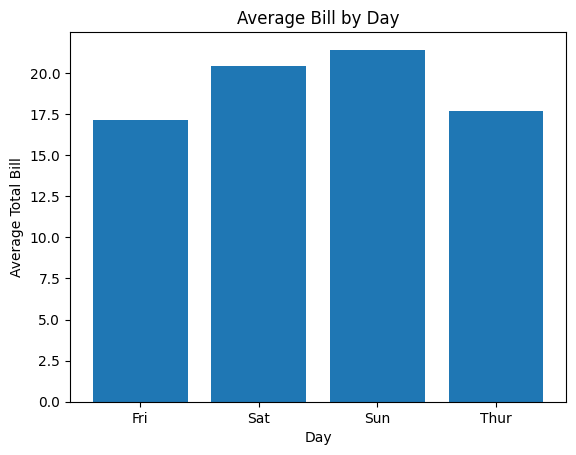

In [30]:
avg_by_day = tips.groupby('day')['total_bill'].mean()

plt.figure()
plt.bar(avg_by_day.index.astype(str), avg_by_day.values)
plt.title("Average Bill by Day")
plt.xlabel("Day")
plt.ylabel("Average Total Bill")
plt.show()


### Student Practice

Create a bar chart showing average `tip_pct` by `time` (Lunch vs Dinner). Give it a title and axis labels.


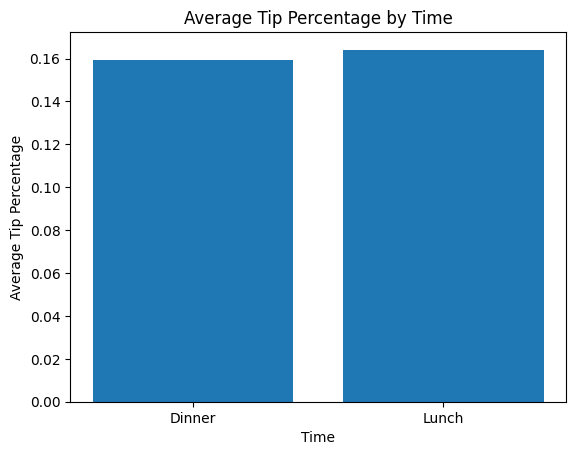

In [31]:
avg_tip_pct_by_time = tips.groupby('time')['tip_pct'].mean()

plt.figure()
plt.bar(avg_tip_pct_by_time.index.astype(str), avg_tip_pct_by_time.values)
plt.title("Average Tip Percentage by Time")
plt.xlabel("Time")
plt.ylabel("Average Tip Percentage")
plt.show()


## Part 10: Saving Your Work

### Demonstration


In [32]:
summary = tips.groupby('day').agg(
    avg_bill=('total_bill','mean'),
    avg_tip=('tip','mean')
).round(2)

summary.to_csv('day_summary.csv')
print("Saved day_summary.csv")
summary


Saved day_summary.csv


,avg_bill,avg_tip
day,,
Fri,17.15,2.73
Sat,20.44,2.99
Sun,21.41,3.26
Thur,17.68,2.77


### Student Practice

Save a CSV called `my_time_summary.csv` containing the average `total_bill` and `tip_pct` grouped by `time`.


In [33]:
my_time_summary = tips.groupby('time').agg(
    avg_total_bill=('total_bill', 'mean'),
    avg_tip_pct=('tip_pct', 'mean')
).round(3)

my_time_summary.to_csv('my_time_summary.csv')
print(my_time_summary)
print("Saved my_time_summary.csv")


        avg_total_bill  avg_tip_pct
time                               
Dinner          20.797        0.160
Lunch           17.169        0.164
Saved my_time_summary.csv


**Reflection:** Saving intermediate results to CSV makes them reusable outside the notebook. A CSV can be opened in spreadsheet software, shared with someone else, loaded into another program, or used later without rerunning all the earlier analysis.


# Mini Project A: Image Metadata Analysis (Image Track — continuing from NumPy lab)

Last week you analyzed a single image with NumPy (shape, brightness, RGB channels). Now you'll use pandas to compare **multiple images** at once — this is exactly how you'd organize a small image dataset for a computer vision project.

## Step 1: Build an image metadata table

For this project, upload **3-5 images** to Colab (reuse your NumPy lab technique), then build a DataFrame — one row per image — with columns: `filename`, `height`, `width`, `channels`, `avg_brightness`, `avg_red`, `avg_green`, `avg_blue`.

### Demonstration: the pattern for one image


In [34]:
from google.colab import files
uploaded = files.upload()


Saving Dbzlj0fEY5X_1.jpg to Dbzlj0fEY5X_1.jpg


In [35]:
from PIL import Image
import numpy as np

filenames = list(uploaded.keys())
print("Uploaded files:", filenames)

# Demonstration: extract metadata for ONE image
sample_name = filenames[0]
img_array = np.array(Image.open(sample_name))

row = {
    'filename': sample_name,
    'height': img_array.shape[0],
    'width': img_array.shape[1],
    'channels': img_array.shape[2] if img_array.ndim == 3 else 1,
    'avg_brightness': np.mean(img_array),
    'avg_red': np.mean(img_array[:,:,0]) if img_array.ndim == 3 else np.mean(img_array),
    'avg_green': np.mean(img_array[:,:,1]) if img_array.ndim == 3 else np.mean(img_array),
    'avg_blue': np.mean(img_array[:,:,2]) if img_array.ndim == 3 else np.mean(img_array),
}
print(row)


Uploaded files: ['Dbzlj0fEY5X_1.jpg']
{'filename': 'Dbzlj0fEY5X_1.jpg', 'height': 1917, 'width': 1080, 'channels': 3, 'avg_brightness': np.float64(112.10629246443453), 'avg_red': np.float64(105.60675824494291), 'avg_green': np.float64(120.53648399312196), 'avg_blue': np.float64(110.17563515523871)}


### Student Practice

Loop over **all** uploaded `filenames` (not just the first one), build a `row` dictionary like above for each image, collect them into a list, and convert the list into a DataFrame using `pd.DataFrame(list_of_rows)`.


In [36]:
# Build one metadata row for every uploaded image
list_of_rows = []

for filename in filenames:
    img = np.array(Image.open(filename))
    row = {
        'filename': filename,
        'height': img.shape[0],
        'width': img.shape[1],
        'channels': img.shape[2] if img.ndim == 3 else 1,
        'avg_brightness': np.mean(img),
        'avg_red': np.mean(img[:, :, 0]) if img.ndim == 3 else np.mean(img),
        'avg_green': np.mean(img[:, :, 1]) if img.ndim == 3 else np.mean(img),
        'avg_blue': np.mean(img[:, :, 2]) if img.ndim == 3 else np.mean(img),
    }
    list_of_rows.append(row)

image_df = pd.DataFrame(list_of_rows)
image_df


,filename,height,width,channels,avg_brightness,avg_red,avg_green,avg_blue
0,Dbzlj0fEY5X_1.jpg,1917,1080,3,112.106,105.607,120.536,110.176


## Step 2: Analyze the image table with pandas

Once you have your image DataFrame, answer using pandas (not manual calculation):

1. Which image has the highest average brightness? (Hint: `.sort_values()` or `.idxmax()`)
2. What is the average brightness across all your images? (`.mean()`)
3. Create a bar chart comparing `avg_brightness` across all images (reuse Part 9's pattern).


Image with highest average brightness: Dbzlj0fEY5X_1.jpg
Average brightness across all images: 112.10629246443453


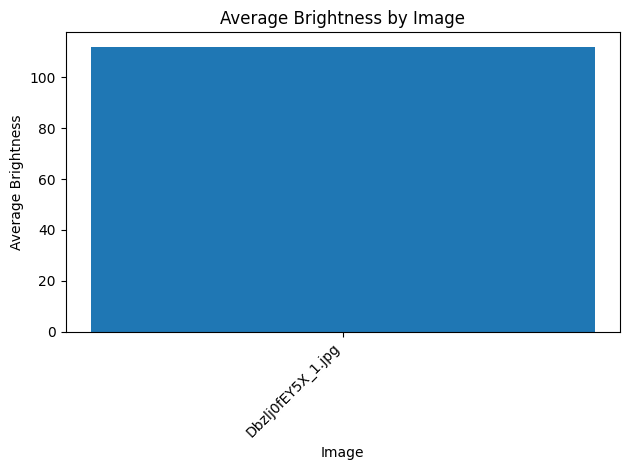

In [37]:
# Analyze the image metadata table with pandas
brightest_image = image_df.loc[image_df['avg_brightness'].idxmax(), 'filename']
overall_average_brightness = image_df['avg_brightness'].mean()

print("Image with highest average brightness:", brightest_image)
print("Average brightness across all images:", overall_average_brightness)

plt.figure()
plt.bar(image_df['filename'].astype(str), image_df['avg_brightness'])
plt.title("Average Brightness by Image")
plt.xlabel("Image")
plt.ylabel("Average Brightness")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Reflection:** A DataFrame lets us store metadata for many images in one structured table, making it easy to compare images, sort by brightness, calculate averages, filter rows, and create charts. Analyzing images one at a time would make these comparisons much more manual.


# Mini Project B: Word Frequency Table (NLP Track — continuing from NumPy lab)

Last week you built bag-of-words vectors and cosine similarity using raw NumPy. Now you'll organize word frequency data into a pandas DataFrame — the standard way this is done in real NLP pipelines.

## Step 1: Build a word frequency table

### Demonstration


In [38]:
sentence = "numpy makes numerical computing fast and numpy makes arrays powerful and pandas makes tables powerful"

tokens = sentence.lower().split()
tokens_array = np.array(tokens)
vocabulary = np.unique(tokens_array)

counts = [np.sum(tokens_array == word) for word in vocabulary]

word_freq = pd.DataFrame({'word': vocabulary, 'count': counts})
word_freq = word_freq.sort_values('count', ascending=False).reset_index(drop=True)
word_freq


,word,count
0,makes,3
1,and,2
2,powerful,2
3,numpy,2
4,arrays,1
5,computing,1
6,numerical,1
7,fast,1
8,pandas,1
9,tables,1


### Student Practice

1. Pick a paragraph of your own (3-4 sentences). Build a `word_freq` DataFrame for it using the same pattern.
2. Use pandas to find the top 5 most frequent words (`.head(5)`).
3. Use pandas to find how many words appear **only once** (Hint: filter where `count == 1`, then check `.shape[0]`).


In [39]:
paragraph = (
    "Pandas makes data analysis easier by organizing information into labeled tables. "
    "DataFrames allow us to filter, sort, group, and summarize data efficiently. "
    "Pandas is useful for preparing datasets before machine learning. "
    "Good data preparation helps analysis and machine learning models produce reliable results."
)

tokens = paragraph.lower().replace(".", "").split()
tokens_array = np.array(tokens)
vocabulary = np.unique(tokens_array)
counts = [np.sum(tokens_array == word) for word in vocabulary]

word_freq = pd.DataFrame({'word': vocabulary, 'count': counts})
word_freq = word_freq.sort_values('count', ascending=False).reset_index(drop=True)

print("Top 5 most frequent words:")
print(word_freq.head(5))

print("\nNumber of words appearing only once:", word_freq[word_freq['count'] == 1].shape[0])


Top 5 most frequent words:
       word  count
0      data      3
1  analysis      2
2  learning      2
3       and      2
4    pandas      2

Number of words appearing only once: 30


## Step 2: Compare word frequency across multiple sentences

### Demonstration: build one table with per-sentence word counts


In [40]:
sentence_a = "machine learning uses numpy and pandas"
sentence_b = "deep learning also uses numpy and pandas heavily"

tokens_a = sentence_a.lower().split()
tokens_b = sentence_b.lower().split()
combined_vocab = np.unique(np.array(tokens_a + tokens_b))

table = pd.DataFrame({
    'word': combined_vocab,
    'sentence_a_count': [np.sum(np.array(tokens_a) == w) for w in combined_vocab],
    'sentence_b_count': [np.sum(np.array(tokens_b) == w) for w in combined_vocab],
})
table


,word,sentence_a_count,sentence_b_count
0,also,0,1
1,and,1,1
2,deep,0,1
3,heavily,0,1
4,learning,1,1
5,machine,1,0
6,numpy,1,1
7,pandas,1,1
8,uses,1,1


### Student Practice

Using the `table` above:
1. Add a new column `difference` = `sentence_a_count - sentence_b_count`.
2. Sort by `difference` to find which words are most unique to sentence A vs sentence B.
3. Which words appear in **both** sentences (count > 0 in both columns)? Filter and display them.


In [41]:
table['difference'] = table['sentence_a_count'] - table['sentence_b_count']

print("Words most unique to sentence A/B:")
print(table.sort_values('difference'))

print("\nWords appearing in both sentences:")
print(table[(table['sentence_a_count'] > 0) & (table['sentence_b_count'] > 0)])


Words most unique to sentence A/B:
       word  sentence_a_count  sentence_b_count  difference
0      also                 0                 1          -1
2      deep                 0                 1          -1
3   heavily                 0                 1          -1
1       and                 1                 1           0
4  learning                 1                 1           0
6     numpy                 1                 1           0
7    pandas                 1                 1           0
8      uses                 1                 1           0
5   machine                 1                 0           1

Words appearing in both sentences:
       word  sentence_a_count  sentence_b_count  difference
1       and                 1                 1           0
4  learning                 1                 1           0
6     numpy                 1                 1           0
7    pandas                 1                 1           0
8      uses                 1

**Reflection:** Pandas makes the word-frequency workflow easier because words and counts can be stored with labels in a DataFrame, then sorted and filtered using simple operations. With raw NumPy arrays, I would have to manage array positions and keep track of which index represents each word. Pandas hides some of that indexing detail, while NumPy makes the underlying array structure and numerical operations more explicit.


# Final Self-Check

- [x] I loaded and inspected a real dataset using pandas
- [x] I filtered, sorted, and created new columns myself
- [x] I cleaned data (duplicates, missing values, dtypes, renaming) without just copying the demo
- [x] I used `groupby()` to summarize data by category
- [x] I merged two tables together
- [x] I built at least one chart from a DataFrame
- [x] I completed Mini Project A (image metadata) or B (word frequency), building the DataFrame myself
- [x] I answered all reflection questions in my own words

## Final Reflection Questions

1. **How is a pandas DataFrame related to a NumPy array?**  
   A DataFrame is a labeled two-dimensional table built around array-like data. It uses NumPy-style numerical operations internally, but adds row/column labels and convenient tools for mixed data types and tabular analysis.

2. **Name one pandas operation that would be painful with raw NumPy arrays and loops instead.**  
   `groupby()` would be much more tedious with raw NumPy arrays because I would have to identify each category, create masks or loops for every group, calculate the statistic separately, and then assemble the results. Pandas does this in a compact operation.

3. **Between the image metadata project and the word frequency project, which felt more like "real world data work" to you, and why?**  
   The image metadata project felt more like real-world data work because multiple files are represented as rows with consistent metadata, and then pandas can be used to compare, summarize, and visualize the dataset.

4. **What's one pandas concept from this lab you still feel shaky on?**  
   I am still a little shaky on `merge()`, especially choosing the correct join type and understanding what happens when keys are missing or repeated. I would like more practice with different join examples.
